# Full Data Analysis + PCA (From Scratch)
Dataset: Breast Cancer Wisconsin (Diagnostic)

This notebook mirrors the pipeline in `src/run_pipeline.py`, but with narrative + plots for submission.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys
sys.path.insert(0, os.path.abspath(".."))
from src.preprocessing import (
    basic_audit, drop_known_junk_columns, encode_target, split_features_target,
    impute_missing, one_hot_encode, winsorize_outliers, standard_scale, robust_scale
)
from src.pca_from_scratch import PCAFromScratch
from src.metrics import reconstruction_rmse


In [10]:
df_raw = pd.read_csv('../data/breast_cancer.csv')
audit = basic_audit(df_raw)
audit


{'n_rows': 569,
 'n_cols': 33,
 'n_duplicates': 0,
 'missing_by_col': {'id': 0,
  'diagnosis': 0,
  'radius_mean': 0,
  'texture_mean': 0,
  'perimeter_mean': 0,
  'area_mean': 0,
  'smoothness_mean': 0,
  'compactness_mean': 0,
  'concavity_mean': 0,
  'concave points_mean': 0,
  'symmetry_mean': 0,
  'fractal_dimension_mean': 0,
  'radius_se': 0,
  'texture_se': 0,
  'perimeter_se': 0,
  'area_se': 0,
  'smoothness_se': 0,
  'compactness_se': 0,
  'concavity_se': 0,
  'concave points_se': 0,
  'symmetry_se': 0,
  'fractal_dimension_se': 0,
  'radius_worst': 0,
  'texture_worst': 0,
  'perimeter_worst': 0,
  'area_worst': 0,
  'smoothness_worst': 0,
  'compactness_worst': 0,
  'concavity_worst': 0,
  'concave points_worst': 0,
  'symmetry_worst': 0,
  'fractal_dimension_worst': 0,
  'Unnamed: 32': 569},
 'dtypes': {'id': 'int64',
  'diagnosis': 'object',
  'radius_mean': 'float64',
  'texture_mean': 'float64',
  'perimeter_mean': 'float64',
  'area_mean': 'float64',
  'smoothness_mean

## Cleaning
- Drop obvious junk columns (`id`, `Unnamed:*`)
- Encode target (`diagnosis`: M→1, B→0)
- Drop duplicates (if any)


In [11]:
df = drop_known_junk_columns(df_raw)
df = encode_target(df, target_col='diagnosis')
df = df.drop_duplicates()
df.head()


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Missing Values
We impute numeric features using **median** (robust), and categorical using `'missing'`.


In [12]:
X, y = split_features_target(df, target_col='diagnosis')
miss = X.isna().sum().sort_values(ascending=False)
miss[miss>0]


Series([], dtype: int64)

In [13]:
X = impute_missing(X, strategy='median')
X = one_hot_encode(X)


## Outliers
We use winsorization (clipping) to reduce the impact of extreme values.
Method used here: **IQR** (k=1.5).


In [ ]:
X, out_stats = winsorize_outliers(X, method='iqr', strength=1.5)
list(out_stats['n_outliers_by_col'].items())[:5]


## Scaling
PCA is variance-based, so scaling is important.
We use **standard scaling** by default.


In [14]:
Xs, mean, std = standard_scale(X)
Xs.describe().T[['mean','std']].head()


,mean,std
radius_mean,-1.373633e-16,1.00088
texture_mean,6.868164e-17,1.00088
perimeter_mean,-1.248757e-16,1.00088
area_mean,-2.185325e-16,1.00088
smoothness_mean,-8.366672e-16,1.00088


## PCA From Scratch (NumPy)
We fit PCA using SVD and choose the smallest number of components that retain **≥95% variance**.


In [15]:
pca = PCAFromScratch(variance_ratio=0.95)
Z = pca.fit_transform(Xs.to_numpy())
pca.n_components_, pca.cumulative_variance_ratio_[-1]


(10, 0.9515688143366668)

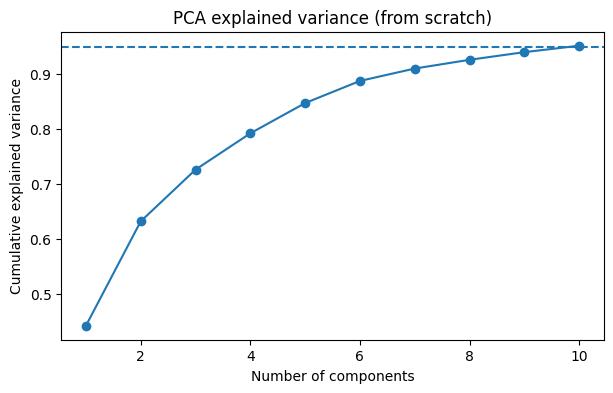

In [16]:
cum = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(7,4))
plt.plot(np.arange(1, len(cum)+1), cum, marker='o')
plt.axhline(0.95, linestyle='--')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA explained variance (from scratch)')
plt.show()


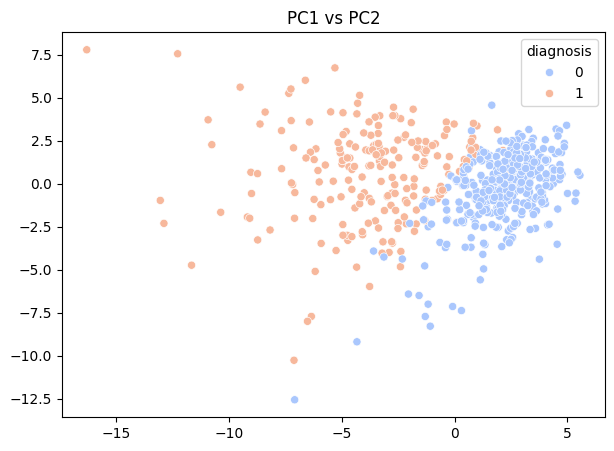

In [17]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=Z[:,0], y=Z[:,1], hue=y, palette='coolwarm', s=35)
plt.title('PC1 vs PC2')
plt.show()


## Reconstruction Error
We reconstruct the scaled data from the PCA space to quantify information loss.


In [18]:
X_rec = pca.inverse_transform(Z)
rmse = reconstruction_rmse(Xs.to_numpy(), X_rec)
rmse


0.22007086509425375